# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is linear when the response variable is expressed as a linear function of one or more explanatory variable.
2. A dummy variable coefficient represents the expected difference in the average dependent variable between group coded as 1 and the reference group coded as 0, while holding all other variable constant.
3. Linear regression can be used for classification, but using Linear Regression for classification is often a bad idea, because linear regression is designed for regression tasks where its goal is to predict continuous values. Its predictions are unbounded, meaning they can fall outside the range [0,1] and do not represent valid probabilities.
4. A linear model is over-fitting when it performs very well on the training data but performs worse on the testing data.
5. The two-stage least squares technique replaces a highly correlated variable with “cleaned” version that contains independent variation, which can reduce instability caused by multi-colinearity. Multi-colinearity happens when predictors are highly correlated, which makes coefficient estimation unstable.
6. Nonlinear relationships can be incorporated by transforming the input features. For example, adding polynomial terms allows the model to capture curvature in the relationship between x and y.
7. The slope coefficient represents the average change in dependent variable y in respect to unit increase in the independent variable x.
8. A train-test split divides the data once into a training set and a testing set, which makes it simple but sensitive to how the split is chosen. In contrast, k-fold cross validation repeatedly splits the data into k folds and averages performance across them, which produces more reliable estimation of model performance.
9. The value of k is typically chosen based on a trade-off between bias and variance. Larger k reduces bias but increases computational cost and variance; Smaller k results in higher bias but lower variance since there are fewer splits.


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [384]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Q1_clean.csv")
display(df.head())
display(df.columns)

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')

                     Price  Review Scores Rating
Neighbourhood                                   
Manhattan       183.664286             91.801496
Staten Island   146.166667             90.843750
Brooklyn        127.747378             92.363497
Queens           96.857233             91.549057
Bronx            75.276498             91.654378
Most expensive borough: Manhattan


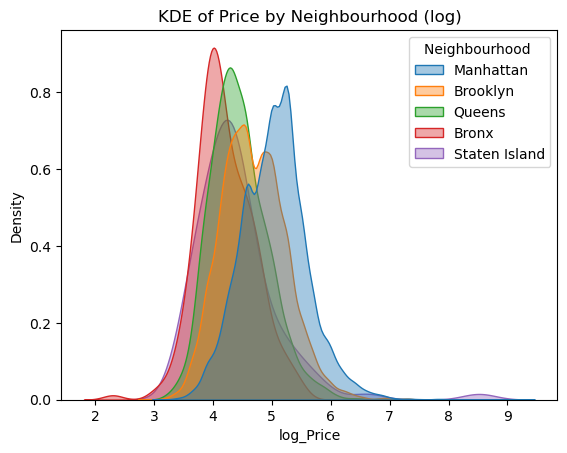

In [385]:
#Q 2.1
means = df.groupby("Neighbourhood ")[["Price", "Review Scores Rating"]].mean().sort_values("Price", ascending=False)
print(means)

most_expensive = means.index[0]
print("Most expensive borough:", most_expensive)

# set log price
df["log_Price"] = np.log(df["Price"])

# plot
sns.kdeplot(
    data=df,
    x="log_Price",
    hue="Neighbourhood ",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("KDE of Price by Neighbourhood (log)")
plt.show()

Most expensive borough: Manhattan

In [386]:
#Q 2.2

from sklearn.linear_model import LinearRegression

# target
y = df["Price"]

# feature with dummy variables
X = pd.get_dummies(df["Neighbourhood "], dtype='int', drop_first=True)

# fit model
model = LinearRegression().fit(X, y)

print("Intercept:", model.intercept_)

# create df for result
pd.DataFrame({
    "variable": model.feature_names_in_,
    "coefficient": model.coef_
})

Intercept: 75.2764976958471


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


I drop the first category, and now each coefficient represents the difference between the mean and the reference group that the mean price is equal to the intercept plus its corresponding coefficient.

In [387]:
#Q 2.3

# target
y = df["Price"]

# feature
X = df[["Review Scores Rating"]]

model2 = LinearRegression().fit(X, y)

print("Intercept:", model2.intercept_)
print("Slope:", model2.coef_[0])

Intercept: 60.87839065711856
Slope: 1.0208266022675305


The slope is the coefficient of the model that represents the average change in price associated with 1 point increase in review score. For every unit increase in **review score rating**, the predicted price changes by the value of the slope, which is roughly 1.020.

In [388]:
#Q 2.4

# target
y = df["Price"]

# get dummies for neighbourhood
dummies = pd.get_dummies(df["Neighbourhood "], drop_first=True)

# feature
X = pd.concat([df[["Review Scores Rating"]], dummies], axis=1)

model3 = LinearRegression().fit(X, y)

print("Intercept:", model3.intercept_)
pd.DataFrame({
    "variable": X.columns,
    "coefficient": model3.coef_
})

Intercept: -23.812561011683925


,variable,coefficient
0,Review Scores Rating,1.081116
1,Brooklyn,51.704240
2,Manhattan,108.228737
3,Queens,21.694600
4,Staten Island,71.766552


After including neighbourhood in the regression, the slope on **review score rating** increases from 1.02 to 1.08, which means that with in the same neighbourhood, higher rating slightly increase the price. The neighbourhood averages change slightly because the model now compares prices while holding ratings constant.

In [389]:
#Q 2.5

# target
y = df["Price"]

# get dummies for neighbourhood
dummies = pd.get_dummies(df["Neighbourhood "], drop_first=True)

# Base rating
X = df[["Review Scores Rating"]].copy()

# Add dummies
X = pd.concat([X, dummies], axis=1)

# create interaction terms
for col in dummies.columns:
    X[col + "_x_rating"] = dummies[col] * df["Review Scores Rating"]

# fit model
model = LinearRegression().fit(X, y)

pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
})

,variable,coefficient
0,Review Scores Rating,0.574311
1,Brooklyn,-16.392990
2,Manhattan,41.315429
3,Queens,28.259701
4,Staten Island,2963.071040
5,Brooklyn_x_rating,0.741165
6,Manhattan_x_rating,0.729703
7,Queens_x_rating,-0.072294
8,Staten Island_x_rating,-31.831748


The slopes are not similar across neighbourhoods. Brooklyn and Manhattan share similar positive slopes, while Queens and the Bronx have small positive slopes. Staten Island has a very large negative slope, which indicates a very different relationship between review scores and price.

In [390]:
#Q 2.6
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

# model 1
X1 = df[["Review Scores Rating"]]
model1 = LinearRegression()
scores1 = cross_val_score(model1, X1, y, cv=kfold, scoring="neg_mean_squared_error")

# model 2
X2 = pd.concat([df[["Review Scores Rating"]], pd.get_dummies(df["Neighbourhood "], drop_first=True)], axis=1)
model2 = LinearRegression()
scores2 = cross_val_score(model2, X2, y, cv=kfold, scoring="neg_mean_squared_error")

# model 3
X3 = X 
model3 = LinearRegression()
scores3 = cross_val_score(model3, X3, y, cv=kfold, scoring="neg_mean_squared_error")

print("Model 1 MSE:", -np.mean(scores1))
print("Model 2 MSE:", -np.mean(scores2))
print("Model 3 MSE:", -np.mean(scores3))



Model 1 MSE: 22079.51235876914
Model 2 MSE: 21074.09738730937
Model 3 MSE: 21334.75481329506


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [391]:
df = pd.read_csv("data/cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

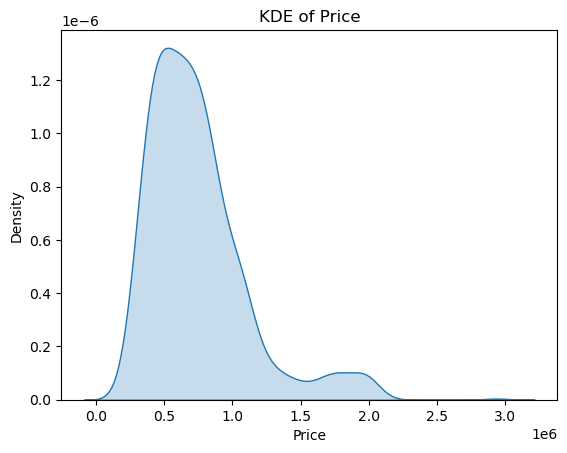

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


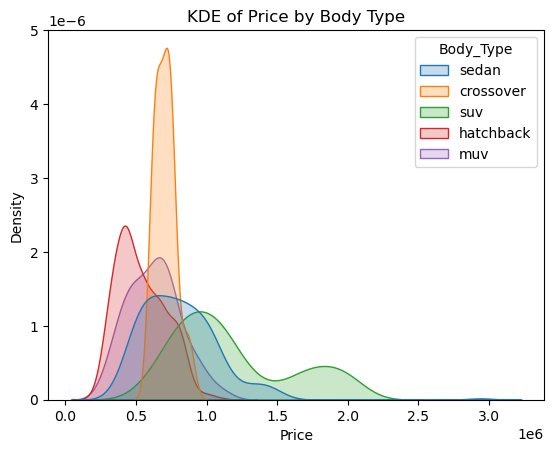

In [392]:
#Q 3.1

display(df["Price"].describe())

sns.kdeplot(data=df, x="Price", fill=True)
plt.title("KDE of Price")
plt.show()

price_by_body = df.groupby("Body_Type")["Price"]
display(price_by_body.describe())

sns.kdeplot(data=df, x="Price", hue="Body_Type", fill=True, common_norm=False)
plt.title("KDE of Price by Body Type")
plt.show()

SUV has the highest average price (single price) as well as the largest standard deviation.

In [393]:
#Q 3.2
df = df[["Price", "Seating_Capacity"]].dropna()

# target
y = df["Price"]

# numerical feature
X = df[["Seating_Capacity"]]

# fit model
model = LinearRegression().fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

# categorical feature
X_cat = pd.get_dummies(df["Seating_Capacity"], drop_first=True)

# fit model
model_cat = LinearRegression().fit(X_cat, y)

print("Intercept:", model_cat.intercept_)
pd.DataFrame({
    "variable": X_cat.columns,
    "coefficient": model_cat.coef_
})

Intercept: 439032.0141018258
Slope: 59267.99803672191
Intercept: 188000.00000001083


,variable,coefficient
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


The slope coefficient is approximately 59,268, which means that each additional seat increase about 59,268 in price. When seat are treated as categorical variable, the differences in price are not roughly linear in the number of seats, because the increases across seating categories are not consistent.

In [ ]:
#Q 3.3
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

df = pd.read_csv("./data/cars_hw.csv")

# create age
df["Age"] = np.max(df["Make_Year"]) - df["Make_Year"]

# select data
X = df[["Age"]].to_numpy()
y = df["Price"].to_numpy()

# create folds
kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = []

# run folds in range from 1 to 20
for d in range(1, 21):
    
    # expand feature X into polynomial features
    expander = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = expander.fit_transform(X)

    scores = []

    # loop through each fold
    for train, test in kf.split(X_poly):

        X_train, X_test = X_poly[train], X_poly[test]
        y_train, y_test = y[train], y[test]

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_hat = model.predict(X_test)

        score = mean_squared_error(y_test, y_hat)
        scores.append(score)

    print("Degree:", d)
    print("Mean score:", np.mean(scores))
    results.append((d, np.mean(scores)))

# pick best degree
best_degree = min(results, key=lambda x: x[1])[0]
print("Best degree:", best_degree)

Degree: 1
Mean score: 97377248063.9968
Degree: 2
Mean score: 97395705968.6351
Degree: 3
Mean score: 96743204818.44327
Degree: 4
Mean score: 96225038252.26138
Degree: 5
Mean score: 95265035514.29655
Degree: 6
Mean score: 95358958404.48004
Degree: 7
Mean score: 94688972031.6542
Degree: 8
Mean score: 93877873486.2038
Degree: 9
Mean score: 93396793529.56712
Degree: 10
Mean score: 93431233817.62924
Degree: 11
Mean score: 93432258701.85208
Degree: 12
Mean score: 93710437065.08386
Degree: 13
Mean score: 96010687052.30403
Degree: 14
Mean score: 95964266567.18286
Degree: 15
Mean score: 96612587404.8726
Degree: 16
Mean score: 97155869465.37799
Degree: 17
Mean score: 97662610616.3517
Degree: 18
Mean score: 99820160382.53609
Degree: 19
Mean score: 100196752082.03008
Degree: 20
Mean score: 100529675444.06131
Best degree: 9


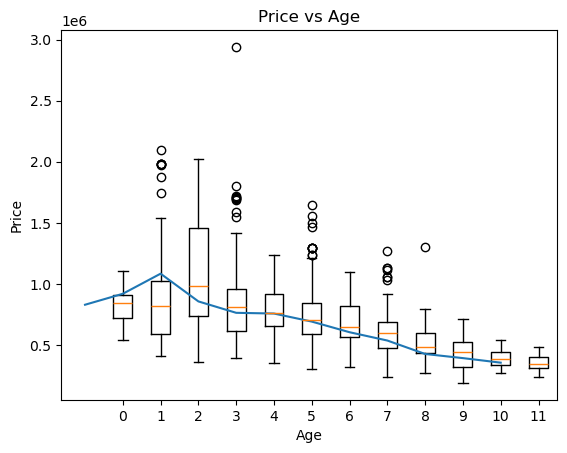

In [395]:
#Q 3.4

# use degree = 9
expander = PolynomialFeatures(degree=9, include_bias=False)
X_poly = expander.fit_transform(X)

# fit model
model = LinearRegression()
model.fit(X_poly, y)

# predictions
y_hat = model.predict(X_poly)

# box plot 
ages = sorted(df["Age"].unique())
plt.boxplot([df[df["Age"] == a]["Price"] for a in ages])
plt.xticks(range(1, len(ages)+1), ages)

# predicted curve 
plot_df = df.copy()
plot_df["Predicted"] = y_hat
plot_df = plot_df.sort_values("Age")
plt.plot(plot_df["Age"], plot_df["Predicted"])
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age")
plt.show()

The model accurately fit the patterns in the data

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [396]:
df = pd.read_csv("data/heart_hw.csv")
display(df.head())
display(df.describe())

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


,Unnamed: 0,age,y
count,103.000000,103.000000,103.000000
mean,52.000000,44.640777,0.271845
std,29.877528,9.797813,0.447086
min,1.000000,8.000000,0.000000
25%,26.500000,41.000000,0.000000
50%,52.000000,47.000000,0.000000
75%,77.500000,52.000000,1.000000
max,103.000000,64.000000,1.000000


In [397]:
#Q 4.1
survival = df.groupby("transplant")["y"].mean()

#a
control = survival["control"]

#b
treatment = survival["treatment"]

#c
ate = treatment - control

print("Control survival rate:", control)
print("Treatment survival rate:", treatment)
print("ATE:", ate)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


In [398]:
#Q 4.2

# get dummies for feature
X = pd.get_dummies(df["transplant"], drop_first=True)

# target
y = df["y"]

# fit model
model = LinearRegression().fit(X, y)

print("Intercept:", model.intercept_)
print(pd.DataFrame({
    "variable": X.columns,
    "coefficient": model.coef_
}))

Intercept: 0.11764705882352974
    variable  coefficient
0  treatment     0.230179


The control survival rate from part 1 matches the intercept of the regression 
(~0.1176), and the ate matches the coefficient on the treatment variable (~0.2301).

Intercept: 0.701956972174095
    variable  coefficient
0  treatment     0.264702
1        age    -0.013607


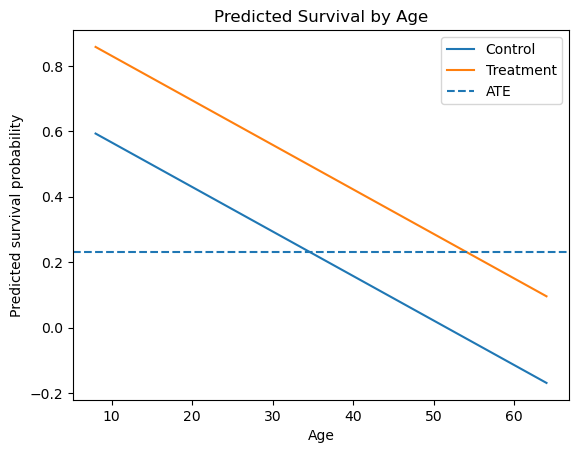

In [399]:
#Q 4.3

# get dummies
X2 = pd.get_dummies(df["transplant"], drop_first=True)

# add feature
X2 = pd.concat([X2,df[["age"]]], axis=1)

# fit model
model2 = LinearRegression().fit(X2, y)

print("Intercept:", model2.intercept_)
print(pd.DataFrame({
    "variable": X2.columns,
    "coefficient": model2.coef_
}))

# age range
ages = np.arange(df["age"].min(), df["age"].max() + 1)

# control group 
plot_control = pd.DataFrame({
    "treatment": 0,
    "age": ages
})

# treatment group 
plot_treatment = pd.DataFrame({
    "treatment": 1,
    "age": ages
})

# predictions
c = model2.predict(plot_control)
t = model2.predict(plot_treatment)

# plot lines
plt.plot(ages, c, label="Control")
plt.plot(ages, t, label="Treatment")

# add ATE line (from part 1)
plt.axhline(y=ate, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()


The coefficient on transplant increases from ~0.2302 to ~0.2647, which indicating a larger estimated effect of receiving a transplant when age is held constant. The intercept (~0.7020) represents the predicted survival probability for a control individual at age 0. The slope on age  is roughly about −0.0136 which indicates that survival probability decreases with age.

The vertical distance between the lines is 0.2647, which represents the treatment effect, which is larger than the ATE from part 1 (~0.2302). Therefore, the ATE underestimates the impact of a transplant at all ages.

Intercept: 0.35486517529945905
        variable  coefficient
0      treatment     0.907751
1            age    -0.005524
2  treatment_age    -0.014591


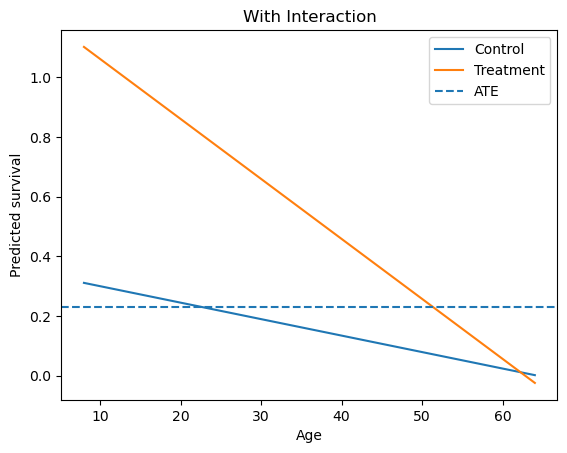

In [400]:
#Q 4.4

# dummy for treatment
X = pd.get_dummies(df["transplant"], drop_first=True)  

# interaction
df["treatment"] = X.iloc[:, 0]
df["treatment_age"] = df["treatment"] * df["age"]

# features
X3 = pd.concat([df[["treatment", "age", "treatment_age"]]], axis=1)

# target
y = df["y"]

# fit model
model3 = LinearRegression().fit(X3, y)

print("Intercept:", model3.intercept_)
print(pd.DataFrame({"variable": X3.columns, "coefficient": model3.coef_}))

plot_control = pd.DataFrame({
    "treatment": 0,
    "age": ages,
    "treatment_age": 0
})
plot_treat = pd.DataFrame({
    "treatment": 1,
    "age": ages,
    "treatment_age": ages
})

c = model3.predict(plot_control)
t = model3.predict(plot_treat)

plt.plot(ages, c, label="Control")
plt.plot(ages, t, label="Treatment")
plt.axhline(y=ate, linestyle="--", label="ATE")
plt.xlabel("Age"); plt.ylabel("Predicted survival")
plt.title("With Interaction"); plt.legend(); plt.show()

When interacting age and transplant, the model changes by making the treatment effect vary with age rather than remaining constant. The coefficient on the interaction term is negative (−0.0146), meaning that the benefit of a transplant decreases as age increases. The treatment and control lines are no longer parallel, as the gap shrinks with age. This shows a pattern that transplants are more beneficial for younger patients.

In [401]:
#Q 4.5
kfold = KFold(n_splits=10, shuffle=True, random_state=100)

# model 1
scores1 = cross_val_score(model, X, y, cv=kfold, scoring="neg_mean_squared_error")

# model 2
scores2 = cross_val_score(model2, X2, y, cv=kfold, scoring="neg_mean_squared_error")

# model 3
scores3 = cross_val_score(model3, X3, y, cv=kfold, scoring="neg_mean_squared_error")

print("Model 1 MSE:", -np.mean(scores1))
print("Model 2 MSE:", -np.mean(scores2))
print("Model 3 MSE:", -np.mean(scores3))

Model 1 MSE: 0.19366383979017968
Model 2 MSE: 0.18171967184387974
Model 3 MSE: 0.18067090272965367


The model 3 works the best.

### 4.6
The model may capture correlation rather than causal effects 
because in reality, transplant patients may already be healthier or systematically different, which creates the risk of biased estimates due to selection bias and omitted variables. Thus, the model could lead to unfair or incorrect prioritization. Furthermore, deploying such a mode could also raises ethical concerns that reduce complex medical decisions to oversimplified predictions.